# Logistic Regression Assignment — Titanic Survival Prediction

## Objective
The goal of this assignment is to build a Logistic Regression model to predict passenger survival on the Titanic dataset.

This notebook covers:

1. Data Exploration and EDA  
2. Data Preprocessing  
3. Logistic Regression Model Building  
4. Model Evaluation  
5. ROC Curve and ROC-AUC Score  
6. Coefficient Interpretation  
7. Cross-validation  
8. Prediction on separate test dataset  
9. Model saving for Streamlit deployment  
10. Interview Questions

## 1. Import Required Libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

# For saving model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The training dataset contains the target column `Survived`.

The test dataset does not contain `Survived`, so we will:
- Train and evaluate the model using a validation split from `Titanic_train.csv`
- Generate survival predictions for `Titanic_test.csv`

In [2]:
train_df = pd.read_csv("Titanic_train.csv")
test_df = pd.read_csv("Titanic_test.csv")

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training Data Shape: (891, 12)
Testing Data Shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 3. Dataset Information

In [3]:
print("Training Dataset Info:")
train_df.info()

print("\nMissing Values in Training Dataset:")
print(train_df.isnull().sum())

print("\nMissing Values in Testing Dataset:")
print(test_df.isnull().sum())

Training Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values in Training Dataset:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare         

## 4. Summary Statistics

In [4]:
print("Numerical Summary:")
display(train_df.describe())

print("Categorical Summary:")
display(train_df.describe(include="object"))

Numerical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Categorical Summary:


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


## 5. Exploratory Data Analysis

### Target Variable Distribution

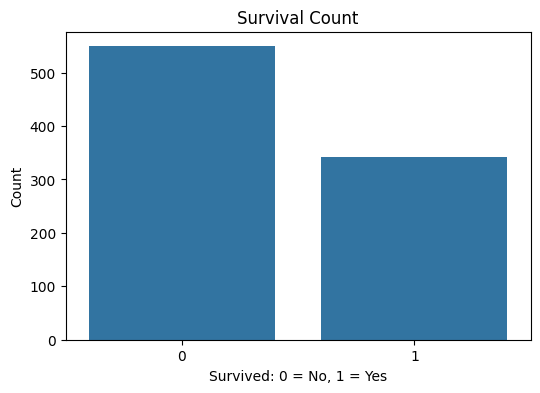

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Survived")
plt.title("Survival Count")
plt.xlabel("Survived: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

print(train_df["Survived"].value_counts())
print(train_df["Survived"].value_counts(normalize=True) * 100)

### Survival by Gender

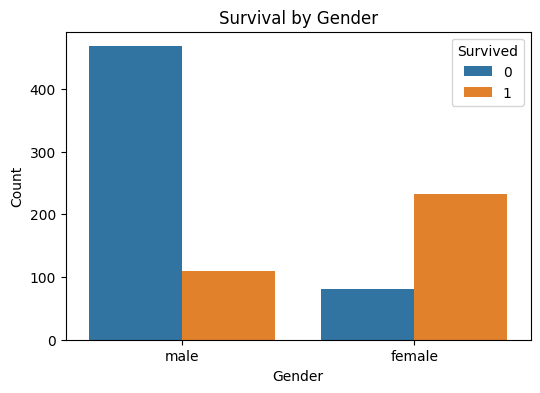

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

display(pd.crosstab(train_df["Sex"], train_df["Survived"], normalize="index") * 100)

### Survival by Passenger Class

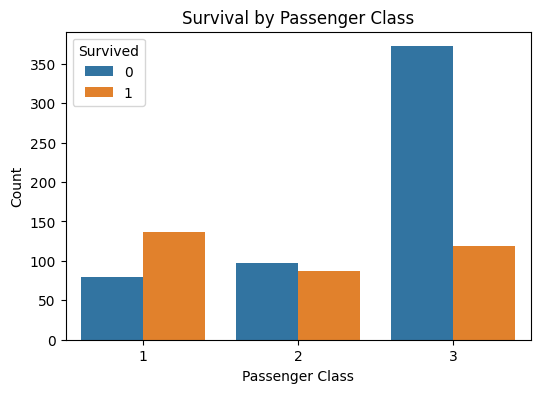

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

display(pd.crosstab(train_df["Pclass"], train_df["Survived"], normalize="index") * 100)

### Age Distribution

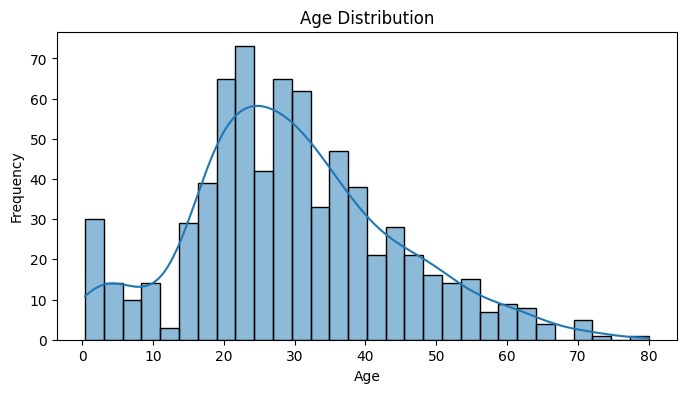

In [8]:
plt.figure(figsize=(8,4))
sns.histplot(train_df["Age"], kde=True, bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Fare Distribution

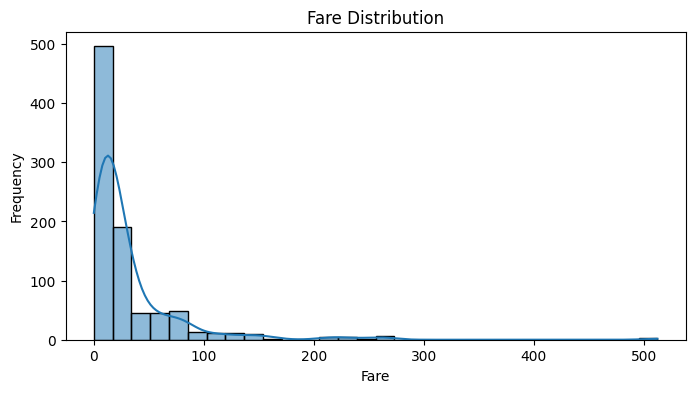

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(train_df["Fare"], kde=True, bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

### Boxplots for Outlier Detection

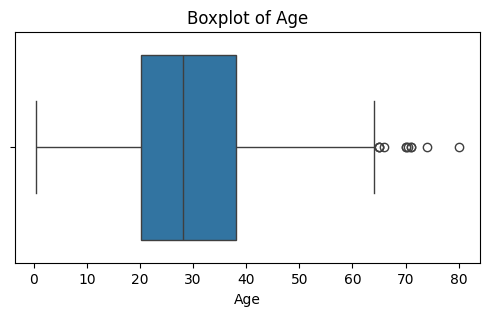

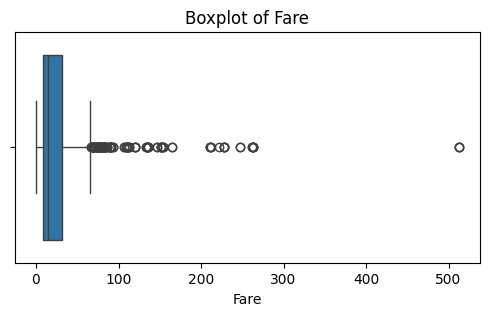

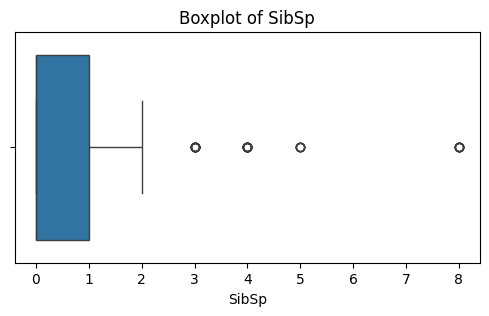

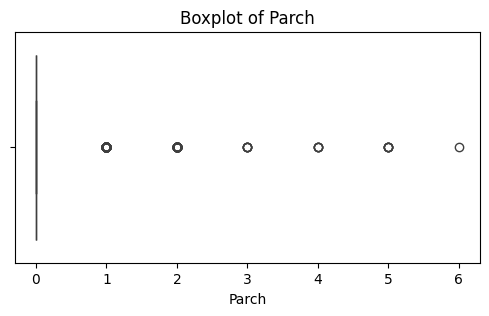

In [10]:
numeric_for_boxplot = ["Age", "Fare", "SibSp", "Parch"]

for col in numeric_for_boxplot:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=train_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Correlation Heatmap

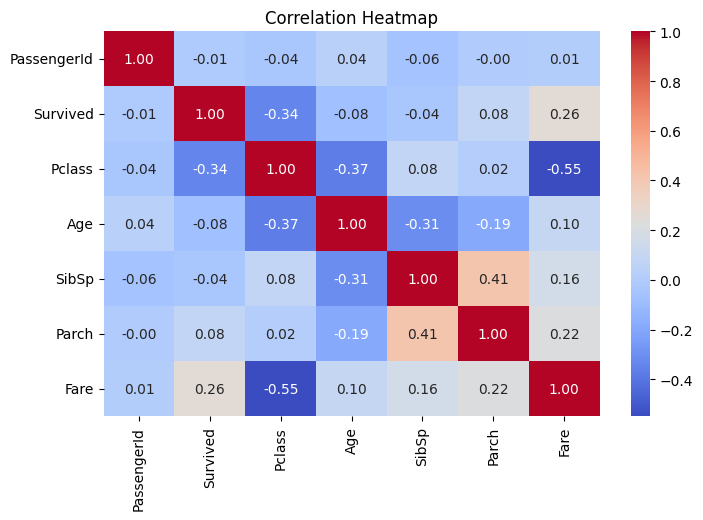

In [11]:
plt.figure(figsize=(8,5))
numeric_corr = train_df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(numeric_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 6. Feature Selection

Columns like `Name`, `Ticket`, and `Cabin` are removed for this basic Logistic Regression assignment because:
- `Name` has mostly unique values
- `Ticket` has many unique values
- `Cabin` has many missing values

Useful features selected:
- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`

In [12]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target = "Survived"

X = train_df[features]
y = train_df[target]

X_test_final = test_df[features]

print("Selected Features:")
print(features)

display(X.head())

Selected Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## 7. Train-Test Split

We split the training dataset into:
- 80% training data
- 20% validation/testing data

In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (712, 7)
X_valid shape: (179, 7)
y_train shape: (712,)
y_valid shape: (179,)


## 8. Data Preprocessing Pipeline

Preprocessing steps:

### Numerical columns
- Missing values filled using median
- Values scaled using StandardScaler

### Categorical columns
- Missing values filled using most frequent value
- Converted into numeric format using One-Hot Encoding

In [14]:
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 9. Build Logistic Regression Model

In [15]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 10. Model Prediction

In [16]:
y_pred = logistic_model.predict(X_valid)
y_pred_proba = logistic_model.predict_proba(X_valid)[:, 1]

print("Predictions completed.")
print("First 10 predictions:", y_pred[:10])
print("First 10 probabilities:", y_pred_proba[:10])

Predictions completed.
First 10 predictions: [0 0 0 0 1 0 1 0 0 0]
First 10 probabilities: [0.06797269 0.04764082 0.15524286 0.03571093 0.67237813 0.44277982
 0.75280449 0.32759601 0.34702495 0.16138012]


## 11. Model Evaluation

We evaluate the model using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC score

In [17]:
accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)
roc_auc = roc_auc_score(y_valid, y_pred_proba)

print("Model Evaluation Scores")
print("-----------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_valid, y_pred))

Model Evaluation Scores
-----------------------
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1 Score : 0.7244
ROC-AUC  : 0.8437

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## 12. Confusion Matrix

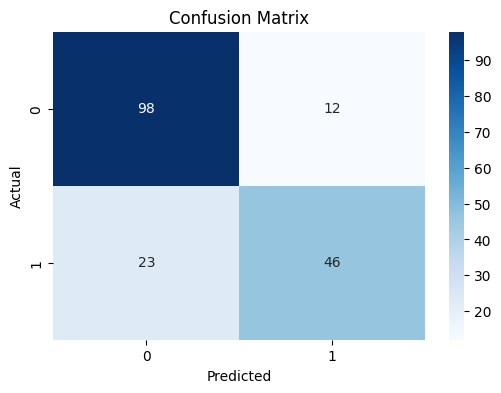

In [18]:
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 13. ROC Curve

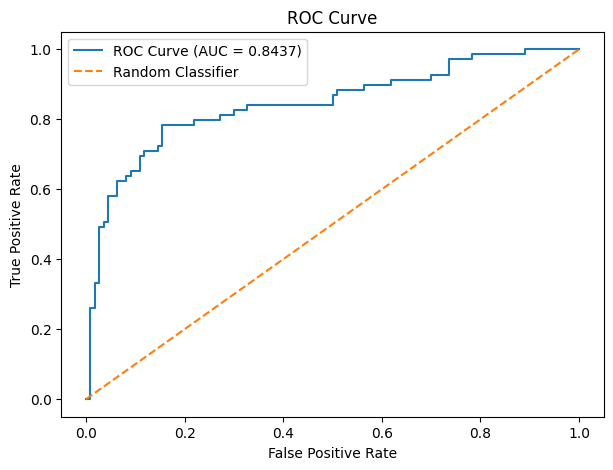

In [19]:
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 14. Cross-Validation

Cross-validation checks whether the model performs consistently across different data splits.

In [20]:
cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

Cross-validation scores: [0.77653631 0.78651685 0.78089888 0.76966292 0.8258427 ]
Mean CV Accuracy: 0.7879
Standard Deviation: 0.0198


## 15. Interpret Logistic Regression Coefficients

Positive coefficient means the feature increases the probability of survival.

Negative coefficient means the feature decreases the probability of survival.

,Feature,Coefficient
5,Sex_female,1.299444
8,Embarked_Q,0.304784
4,Fare,0.100269
7,Embarked_C,0.032247
3,Parch,-0.066424
2,SibSp,-0.260607
9,Embarked_S,-0.358305
1,Age,-0.502815
0,Pclass,-0.921972
6,Sex_male,-1.320718


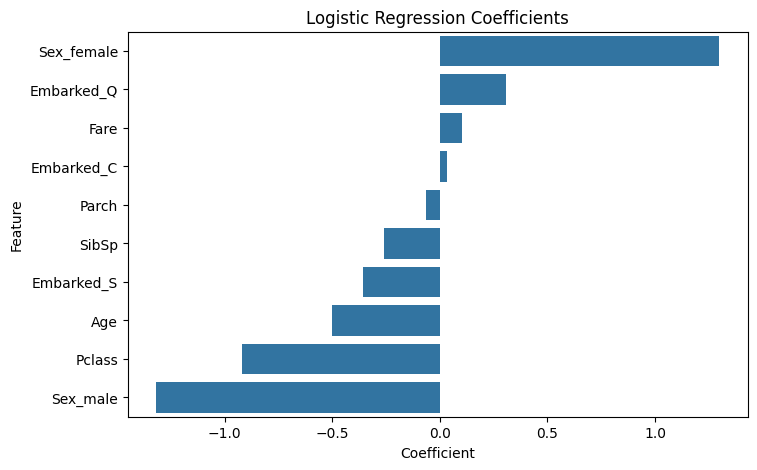

In [21]:
# Train preprocessing separately to get encoded feature names
logistic_model.fit(X_train, y_train)

preprocessor_fitted = logistic_model.named_steps["preprocessor"]
classifier_fitted = logistic_model.named_steps["classifier"]

encoded_cat_features = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)

all_feature_names = list(numeric_features) + list(encoded_cat_features)

coefficients = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": classifier_fitted.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

display(coefficients)

plt.figure(figsize=(8,5))
sns.barplot(data=coefficients, x="Coefficient", y="Feature")
plt.title("Logistic Regression Coefficients")
plt.show()

## 16. Prediction on Provided Titanic Test Dataset

The separate `Titanic_test.csv` file does not contain actual `Survived` labels, so we only generate predictions.

In [22]:
final_test_predictions = logistic_model.predict(X_test_final)
final_test_probabilities = logistic_model.predict_proba(X_test_final)[:, 1]

submission_df = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived_Prediction": final_test_predictions,
    "Survival_Probability": final_test_probabilities
})

display(submission_df.head())

submission_df.to_csv("Titanic_Logistic_Regression_Predictions.csv", index=False)

print("Predictions saved as Titanic_Logistic_Regression_Predictions.csv")

,PassengerId,Survived_Prediction,Survival_Probability
0,892,0,0.129754
1,893,0,0.337036
2,894,0,0.135317
3,895,0,0.093235
4,896,1,0.555014


Predictions saved as Titanic_Logistic_Regression_Predictions.csv


## 17. Save Model for Streamlit Deployment

In [23]:
joblib.dump(logistic_model, "titanic_logistic_regression_model.pkl")

print("Model saved as titanic_logistic_regression_model.pkl")

Model saved as titanic_logistic_regression_model.pkl


## 18. Key Insights

1. Gender is an important factor in survival prediction.
2. Passenger class is strongly related to survival probability.
3. Fare and age also contribute to survival prediction.
4. Logistic Regression is suitable because the target variable is binary: survived or not survived.
5. The ROC-AUC score helps evaluate how well the model separates survivors from non-survivors.

## 19. Interview Questions

### Q1. What is the difference between precision and recall?

**Precision** tells us, out of all passengers predicted as survived, how many actually survived.

Formula:

`Precision = True Positives / (True Positives + False Positives)`

Precision is important when false positives are costly.

**Recall** tells us, out of all passengers who actually survived, how many were correctly predicted as survived.

Formula:

`Recall = True Positives / (True Positives + False Negatives)`

Recall is important when false negatives are costly.

### Simple Difference

- Precision focuses on correctness of positive predictions.
- Recall focuses on capturing all actual positive cases.

---

### Q2. What is cross-validation, and why is it important in binary classification?

Cross-validation is a technique where the dataset is divided into multiple parts or folds. The model is trained on some folds and tested on the remaining fold. This process is repeated multiple times.

It is important because:

1. It gives a more reliable estimate of model performance.
2. It reduces dependency on a single train-test split.
3. It helps detect overfitting.
4. It is useful when the dataset size is limited.
5. It helps compare different models fairly.

## 20. Final Conclusion

In this assignment, Logistic Regression was applied to predict Titanic passenger survival. The dataset was cleaned by handling missing values and encoding categorical variables. The model was trained using selected features such as passenger class, gender, age, fare, siblings/spouses, parents/children, and embarkation point.

The model was evaluated using accuracy, precision, recall, F1-score, and ROC-AUC score. The ROC curve was plotted to understand the model's classification ability. Coefficients were interpreted to understand the influence of different features on survival probability.

This assignment shows that Logistic Regression is a useful and interpretable algorithm for binary classification problems.